In [1]:
import yfinance as yf
import pandas as pd

In [2]:
data = yf.download("^GSPC", start="2016-06-21", end="2026-06-21")

[*********************100%***********************]  1 of 1 completed


^ means caret 
caret (^) tells Yahoo Finance that you are downloading data for an index, rather than an individual tradeable company stock


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
2016-06-21,2088.899902,2093.659912,2083.020020,2085.189941,3232880000
2016-06-22,2085.449951,2099.709961,2084.360107,2089.750000,3168160000
2016-06-23,2113.320068,2113.320068,2092.800049,2092.800049,3297940000
2016-06-24,2037.410034,2103.810059,2032.569946,2103.810059,7597450000
2016-06-27,2000.540039,2031.449951,1991.680054,2031.449951,5431220000


### dropping multiindex

In [4]:
data.columns = data.columns.droplevel(level=1)

In [5]:
data.head()

Price,Close,High,Low,Open,Volume
2016-06-21,2088.899902,2093.659912,2083.020020,2085.189941,3232880000
2016-06-22,2085.449951,2099.709961,2084.360107,2089.750000,3168160000
2016-06-23,2113.320068,2113.320068,2092.800049,2092.800049,3297940000
2016-06-24,2037.410034,2103.810059,2032.569946,2103.810059,7597450000
2016-06-27,2000.540039,2031.449951,1991.680054,2031.449951,5431220000


In [6]:
data.shape

(2513, 5)

### checking missing

In [7]:
data.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
sp500 = data[['Close']].copy()

sp500.head()

Price,Close
2016-06-21,2088.899902
2016-06-22,2085.449951
2016-06-23,2113.320068
2016-06-24,2037.410034
2016-06-27,2000.540039


In [9]:
sp500.to_csv("sp500.csv")

Historical market prices collected

Clean dataset created

Ready for return calculation

### Phase 2

In [10]:
import numpy as np

In [11]:
sp500['Log_return']=np.log(sp500['Close']/sp500['Close'].shift(1))

In [12]:
sp500.dropna(inplace=True)

sp500.describe()

In [13]:
sp500.columns.name = None

In [14]:
sp500

,Close,Log_return
2016-06-22,2085.449951,-0.001653
2016-06-23,2113.320068,0.013276
2016-06-24,2037.410034,-0.036581
2016-06-27,2000.540039,-0.018262
2016-06-28,2036.089966,0.017614
...,...,...
2026-06-12,7431.459961,0.005013
2026-06-15,7554.290039,0.016393
2026-06-16,7511.350098,-0.005700
2026-06-17,7420.100098,-0.012223


here we use the clean data of close column convert price into return , and for smooth caalculation we use og tranformation
to obtain a stationary financial time series
appropriate for volatility modeling

### Phase 3  Eda

In [15]:
import matplotlib.pyplot as plt

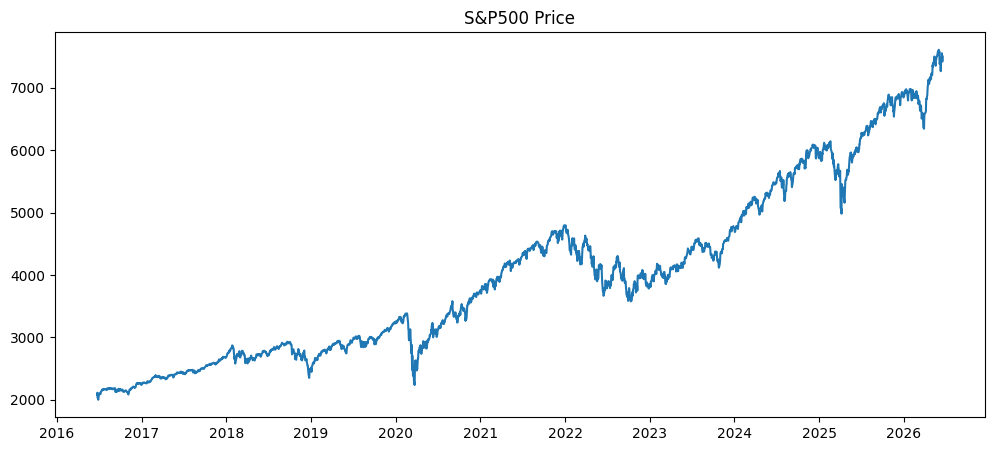

In [16]:
plt.figure(figsize=(12,5))

plt.plot(sp500['Close'])

plt.title("S&P500 Price")
plt.show()


analyses := this is the data from 2016 to 2026 mid june correct 10 year timestamp , we can se the trend , seasonality 
clearly this is non stationary .

In [17]:
sp500['return']=(sp500['Close']/sp500['Close'].shift(1))

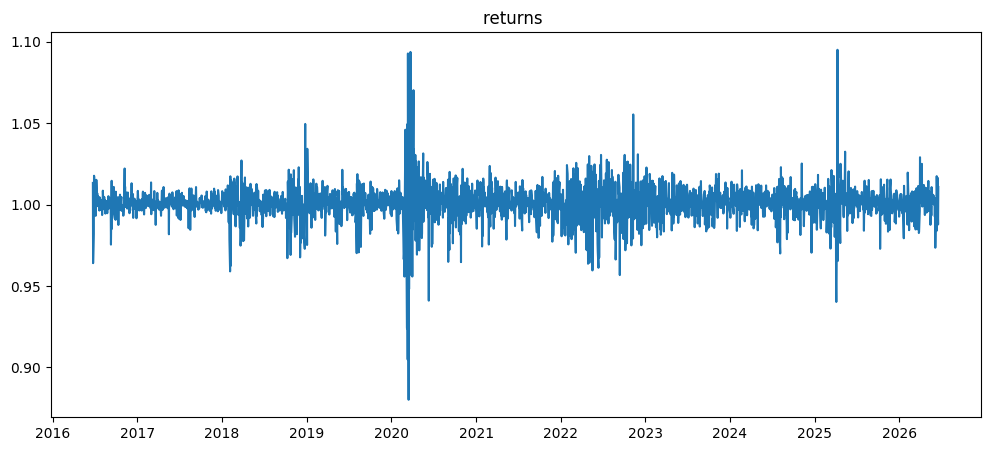

In [18]:
plt.figure(figsize=(12,5))

plt.plot(sp500['return'])

plt.title("returns ")
plt.show()

## returns and log return see diff. log centered around 0

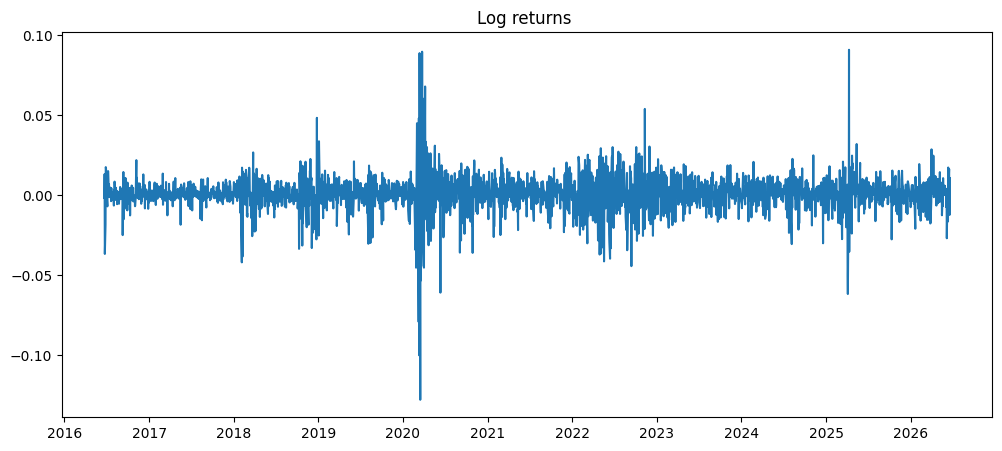

In [19]:
plt.figure(figsize=(12,5))

plt.plot(sp500['Log_return'])

plt.title("Log returns ")
plt.show()

### as we apply log transformation over returns , we  succeeding to convert mean is equal to zero , but 
### there is substensial variance , which is reflection of seasonality

In [20]:
sp500["Squared_return"]=(sp500['Log_return']**2)

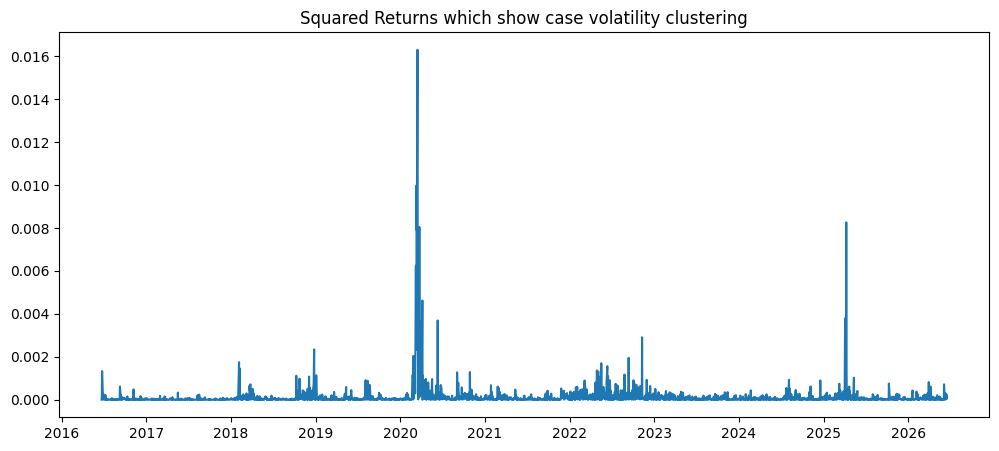

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500['Squared_return']
)

plt.title(
    "Squared Returns which show case volatility clustering"
)

plt.show()

why squaring beause return gives use volatility variance , which also has direction , but in volatility modeling
we require only magnitude 

### Phase 4 Stationary test (ADF)

In [22]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Sumit\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [23]:
from statsmodels.tsa.stattools import adfuller

In [24]:
result=adfuller(sp500['Log_return'])

In [25]:
result

(-15.919311959997367,
 7.957407878307674e-29,
 8,
 2503,
 {'1%': -3.4329652692893364,
  '5%': -2.8626954126892405,
  '10%': -2.567385070816339},
 -15310.497802866106)

In [26]:
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -15.919311959997367
p-value: 7.957407878307674e-29


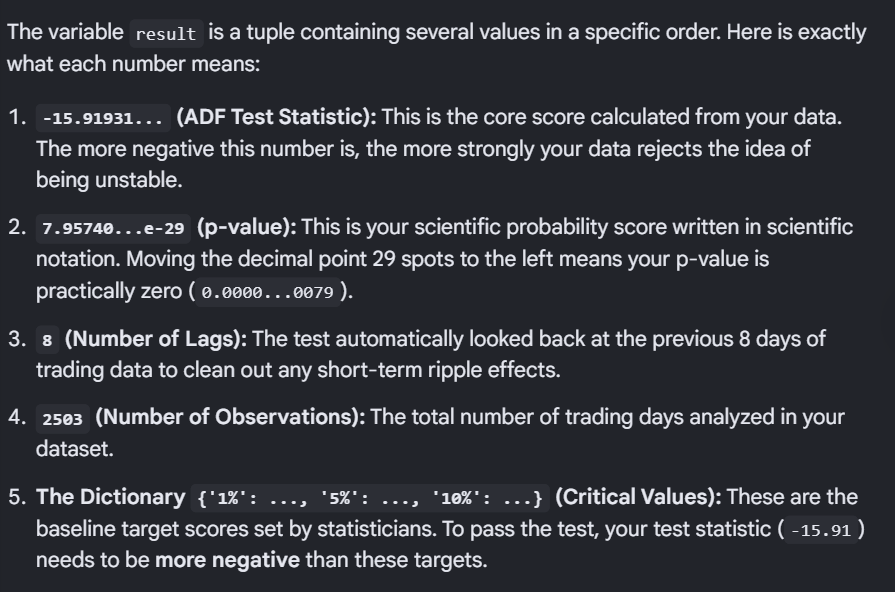

In [27]:
result[4]

{'1%': -3.4329652692893364,
 '5%': -2.8626954126892405,
 '10%': -2.567385070816339}

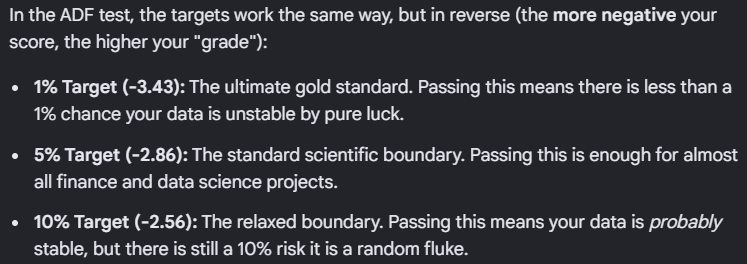

## result is  S&P 500 log returns are incredibly clean, stationary, and ready for your next coding step.

The Augmented Dickey-Fuller test strongly rejects the null hypothesis of a unit root. The return series is stationary and suitable for volatility modeling.

## Phase 5 Volatility Clustering Test

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

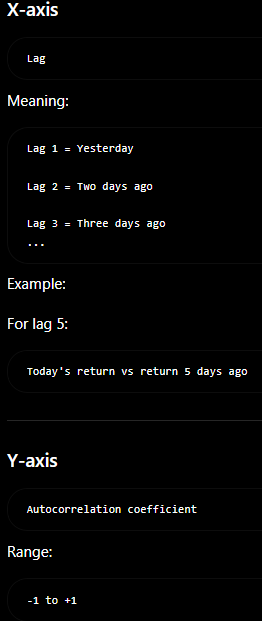

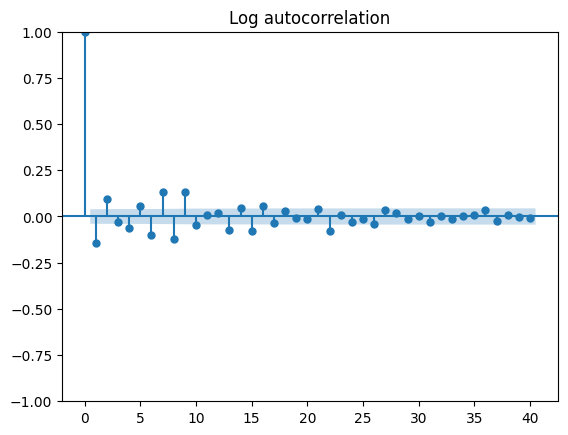

In [29]:
plot_acf(sp500['Log_return'],lags=40)
plt.title("Log autocorrelation")
plt.show()

return acf shows as they are most of zero
Almost every bar:

Near zero
and inside confidence bands.

Meaning:

Today's return
does NOT predict
future return
This is extremely common.

Financial markets are approximately:

Return unpredictable
This is why price prediction is difficult.

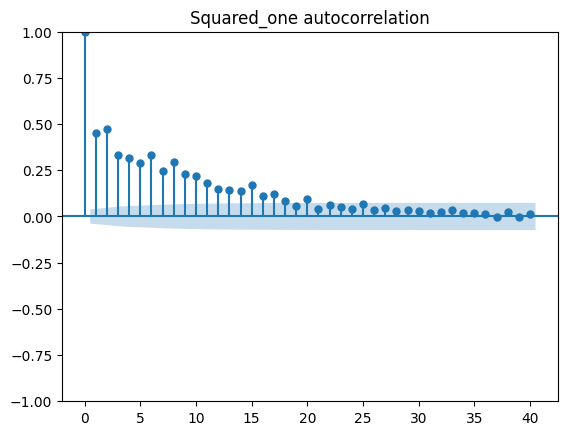

In [30]:
plot_acf(sp500['Squared_return'],lags=40)
plt.title("Squared_one autocorrelation")
plt.show()

this means volatility , 
if market volatility is high today:

High probability
volatility remains high tomorrow

If volatility is low today:

High probability
volatility remains low tomorrow

### as acf is almost zero whch means no mean sructure data :- so not to use ar family 

### as squared return acf is significant so use garch , as this is volatility strutured data

The project objective was volatility forecasting rather than return forecasting. ACF analysis showed minimal serial correlation in returns but significant autocorrelation in squared returns, indicating volatility clustering and conditional heteroskedasticity. Therefore, a GARCH framework was more appropriate than ARIMA for modeling the conditional variance process.

### Phase 6

Arch effect test 

In [31]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(sp500['Log_return'])

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 810.5183428951461
p-value: 1.1303043824921111e-167


The ARCH-LM test produced a statistic of 810.52 with a p-value below 0.001, strongly rejecting the null hypothesis of homoskedasticity. The result confirms the presence of conditional heteroskedasticity and provides formal statistical justification for fitting a GARCH volatility model.

## The arch package expects returns in percentages.

In [32]:
pip install arch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Sumit\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [33]:
returns=sp500['Log_return']*100

In [34]:
## GARCH(1,1)  fit model

In [35]:
from arch import arch_model
garch=arch_model(
    returns,
    vol='Garch',
    p=1,
    q=1,
    mean='Constant'
)

In [36]:
results = garch.fit()


Iteration:      1,   Func. Count:      6,   Neg. LLF: 44473459362.449615
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1455993343.3232002
Iteration:      3,   Func. Count:     22,   Neg. LLF: 4163.468111019874
Iteration:      4,   Func. Count:     28,   Neg. LLF: 3646.7898603458525
Iteration:      5,   Func. Count:     36,   Neg. LLF: 4492.617058830134
Iteration:      6,   Func. Count:     42,   Neg. LLF: 3244.652115049562
Iteration:      7,   Func. Count:     47,   Neg. LLF: 3244.490684529207
Iteration:      8,   Func. Count:     52,   Neg. LLF: 3244.46999657751
Iteration:      9,   Func. Count:     57,   Neg. LLF: 3244.4657786837324
Iteration:     10,   Func. Count:     62,   Neg. LLF: 3244.4657662832365
Iteration:     11,   Func. Count:     67,   Neg. LLF: 3244.465765667813
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3244.465765667813
            Iterations: 11
            Function evaluations: 67
            Gradient evaluations

In [37]:
print(results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3244.47
Distribution:                  Normal   AIC:                           6496.93
Method:            Maximum Likelihood   BIC:                           6520.25
                                        No. Observations:                 2512
Date:                Tue, Jun 23 2026   Df Residuals:                     2511
Time:                        12:40:49   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0832  1.499e-02      5.553  2.810e-08 [5.385e-0

In [38]:
#Extract Conditional Volatility
sp500['GARCH_Vol'] = results.conditional_volatility

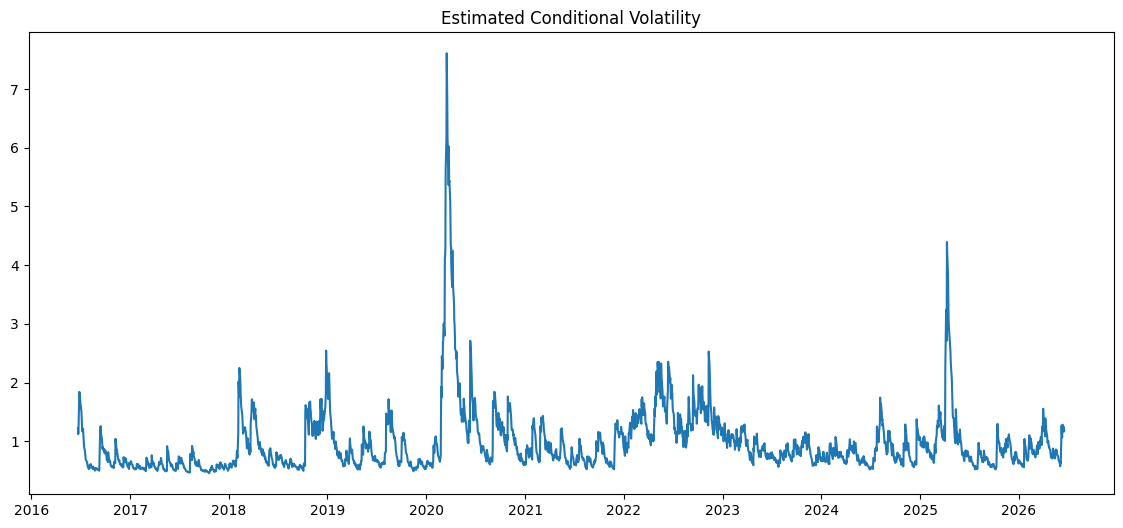

In [39]:

plt.figure(figsize=(14,6))

plt.plot(
    sp500.index,
    sp500['GARCH_Vol']
)

plt.title(
    'Estimated Conditional Volatility'
)

plt.show()

this is conditionl voltility graph , means volatility depend on latest market  state , grac estiate this as from the equation
it contains memory function which fade with time , so for a timeperiod the volatility become highest to high , do not sudden drop this is volatility , risk 
forecasting

## phase 7

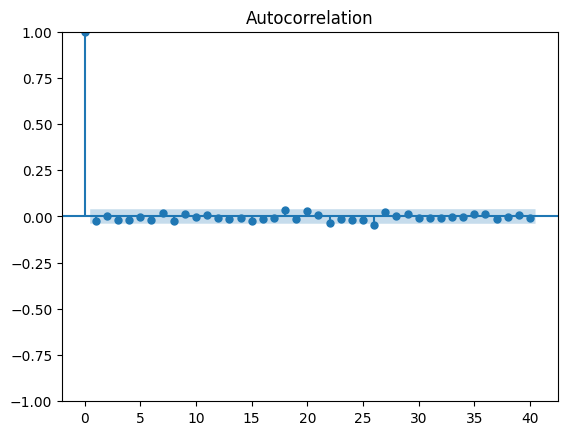

In [40]:
from statsmodels.graphics.tsaplots import plot_acf
std_resid = results.std_resid
plot_acf(std_resid, lags=40)
plt.show()

Any structure left? no

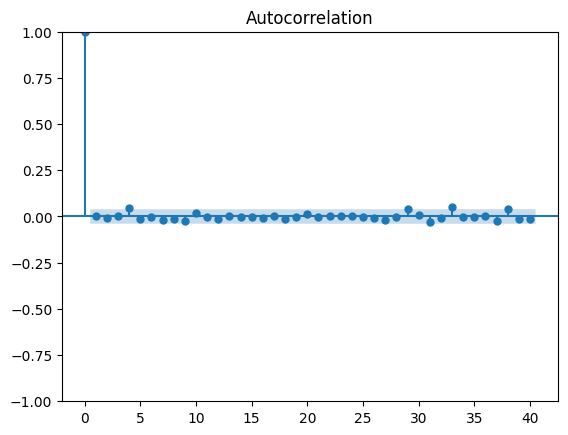

In [41]:
plot_acf(std_resid**2, lags=40)
plt.show()

Any volatility clustering left?

In [42]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb1 = acorr_ljungbox(
    std_resid,
    lags=[10],
    return_df=True
)

print(lb1)

     lb_stat  lb_pvalue
10  7.540497   0.673621


In [43]:
lb2 = acorr_ljungbox(
    std_resid**2,
    lags=[10],
    return_df=True
)

print(lb2)

      lb_stat  lb_pvalue
10  10.812095   0.372344


### Phase 8: Volatility Forecasting

In [47]:
forecast = results.forecast(horizon=10)

In [48]:
forecast.variance.tail()

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
2026-06-18,1.337386,1.334234,1.331178,1.328213,1.325338,1.322549,1.319845,1.317222,1.314678,1.312211


In [49]:
np.sqrt(forecast.variance.tail())

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
2026-06-18,1.156454,1.155091,1.153767,1.152481,1.151233,1.150021,1.148845,1.147703,1.146594,1.145518


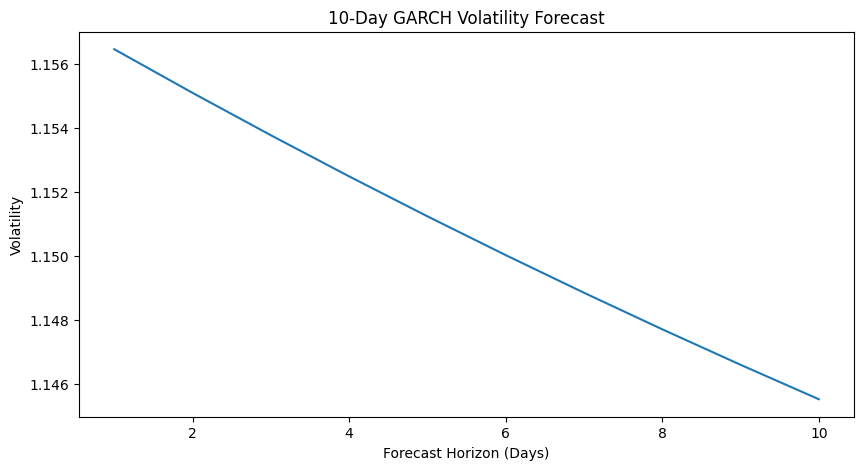

In [50]:
future_vol = np.sqrt(
    forecast.variance.iloc[-1]
)

plt.figure(figsize=(10,5))

plt.plot(
    range(1,11),
    future_vol
)

plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("Volatility")
plt.title("10-Day GARCH Volatility Forecast")

plt.show()

### Phase 9 — Benchmark Comparison

### Rolling Volatility
Model 1

In [46]:
rolling_vol = (
    returns.rolling(20)
    .std()
)

### EWMA (Riskmetrics)
Model 2

In [51]:
lambda_ = 0.94

ewma_var = np.zeros(len(returns)) #a plain NumPy array.

ewma_var[0] = returns.var()

for t in range(1, len(returns)):
    ewma_var[t] = (
        lambda_ * ewma_var[t-1]
        + (1-lambda_) * returns.iloc[t-1]**2
    )

ewma_vol = np.sqrt(ewma_var)

### GARCH
model 3

In [52]:
results.conditional_volatility

2016-06-22    1.226732
2016-06-23    1.122074
2016-06-24    1.142758
2016-06-27    1.842141
2016-06-28    1.835744
                ...   
2026-06-12    1.281939
2026-06-15    1.178634
2026-06-16    1.246772
2026-06-17    1.165788
2026-06-18    1.188321
Name: cond_vol, Length: 2512, dtype: float64

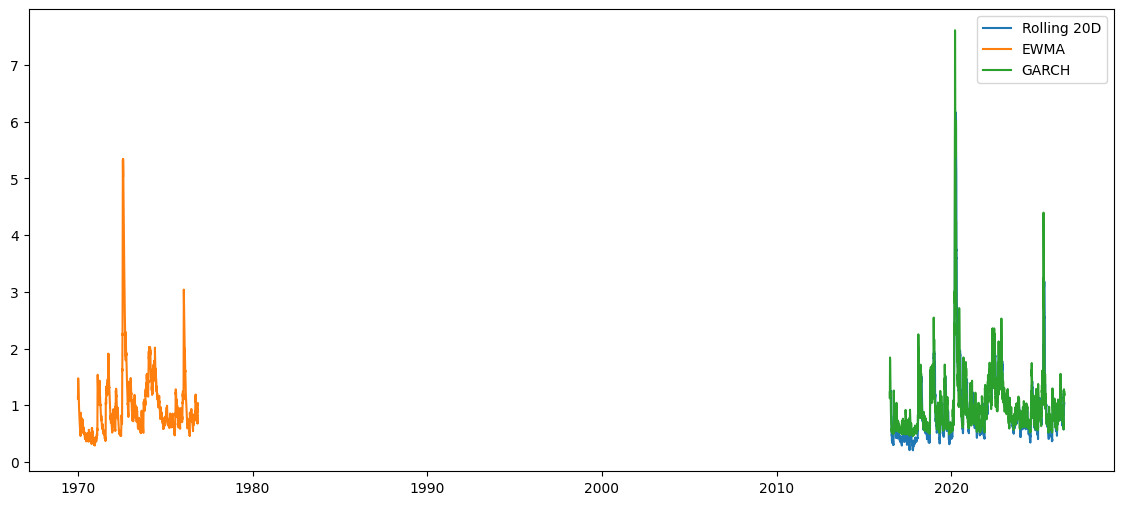

In [55]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_vol,
    label="Rolling 20D"
)

plt.plot(
    ewma_vol,
    label="EWMA"
)

plt.plot(
    results.conditional_volatility,
    label="GARCH"
)

plt.legend()
plt.show()

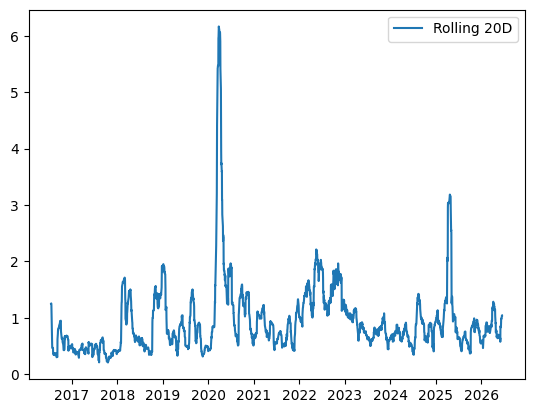

In [59]:
plt.plot(
    rolling_vol,
    label="Rolling 20D"
)
plt.legend()

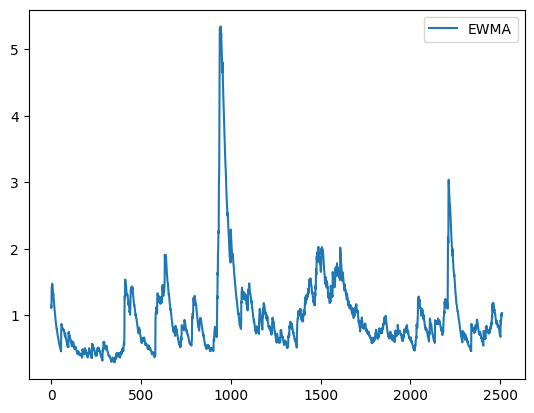

In [60]:
plt.plot(
    ewma_vol,
    label="EWMA"
)
plt.legend()

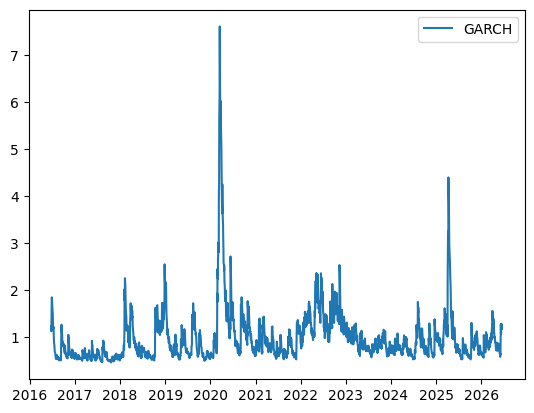

In [61]:
plt.plot(
    results.conditional_volatility,
    label="GARCH"
)
plt.legend()


In [62]:
ewma_vol = pd.Series(
    ewma_vol,
    index=returns.index
)

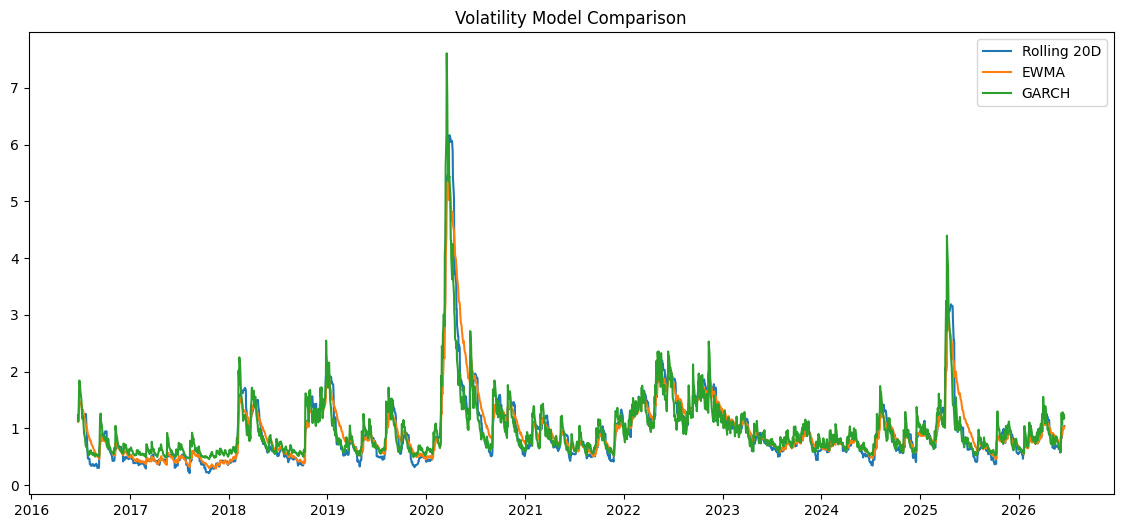

In [63]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_vol.index,
    rolling_vol,
    label='Rolling 20D'
)

plt.plot(
    ewma_vol.index,
    ewma_vol,
    label='EWMA'
)

plt.plot(
    results.conditional_volatility.index,
    results.conditional_volatility,
    label='GARCH'
)

plt.legend()
plt.title("Volatility Model Comparison")
plt.show()

### phase 11 Forecast accuraacy backtesting

In [69]:
train = returns[:'2024-12-31']
test = returns['2025-01-01':]
print("Training",train.index.min(), train.index.max())
print("Testing",test.index.min(), test.index.max())

Training 2016-06-22 00:00:00 2024-12-31 00:00:00
Testing 2025-01-02 00:00:00 2026-06-18 00:00:00


In [70]:
from arch import arch_model

garch = arch_model(
    train,              #training garch on training set
    vol='GARCH',
    p=1,
    q=1
)

garch_fit = garch.fit(disp='off')

### Realized Volatility
ground truth

In [72]:
realized_vol = (test.rolling(20).std())   #actual volatility 

In [89]:
rolling_forecast=(returns.rolling(50).std().loc[test.index])

EWMA Forecast

In [90]:
lambda_ = 0.94

ewma_var = np.zeros(len(returns))

ewma_var[0] = returns.var()

for t in range(1, len(returns)):
    ewma_var[t] = (
        lambda_ * ewma_var[t-1]
        + (1-lambda_) * returns.iloc[t-1]**2
    )

ewma_vol = np.sqrt(ewma_var)

ewma_vol = pd.Series(
    ewma_vol,
    index=returns.index
)

ewma_forecast = ewma_vol.loc[test.index]

### Rolling GARCH Forecast
For every test day:

Train until yesterday,
Forecast tomorrow,
Move forward,
Repeat

In [91]:
garch_forecast = []

history = train.copy()

for i in range(len(test)):

    model = arch_model(
        history,
        vol='GARCH',
        p=1,
        q=1
    )

    fit = model.fit(
        disp='off'
    )

    pred = fit.forecast(
        horizon=1
    )

    forecast_vol = np.sqrt(
        pred.variance.iloc[-1,0]
    )

    garch_forecast.append(
        forecast_vol
    )

    history = pd.concat(
        [history,
         test.iloc[i:i+1]]
    )

In [92]:
garch_forecast = pd.Series(
    garch_forecast,
    index=test.index
)

### Align Data

In [93]:
comparison = pd.concat(
    [
        realized_vol,
        rolling_forecast,
        ewma_forecast,
        garch_forecast
    ],
    axis=1
)

comparison.columns = [
    "Realized",
    "Rolling",
    "EWMA",
    "GARCH"
]

comparison = comparison.dropna()

### calculate error

In [94]:
from sklearn.metrics import mean_squared_error

rmse_roll = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["Rolling"]
    )
)

rmse_ewma = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["EWMA"]
    )
)

rmse_garch = np.sqrt(
    mean_squared_error(
        comparison["Realized"],
        comparison["GARCH"]
    )
)

In [95]:
print("Rolling RMSE:", rmse_roll)
print("EWMA RMSE:", rmse_ewma)
print("GARCH RMSE:", rmse_garch)

Rolling RMSE: 0.42009714506362766
EWMA RMSE: 0.23471356153554432
GARCH RMSE: 0.3125011906390604


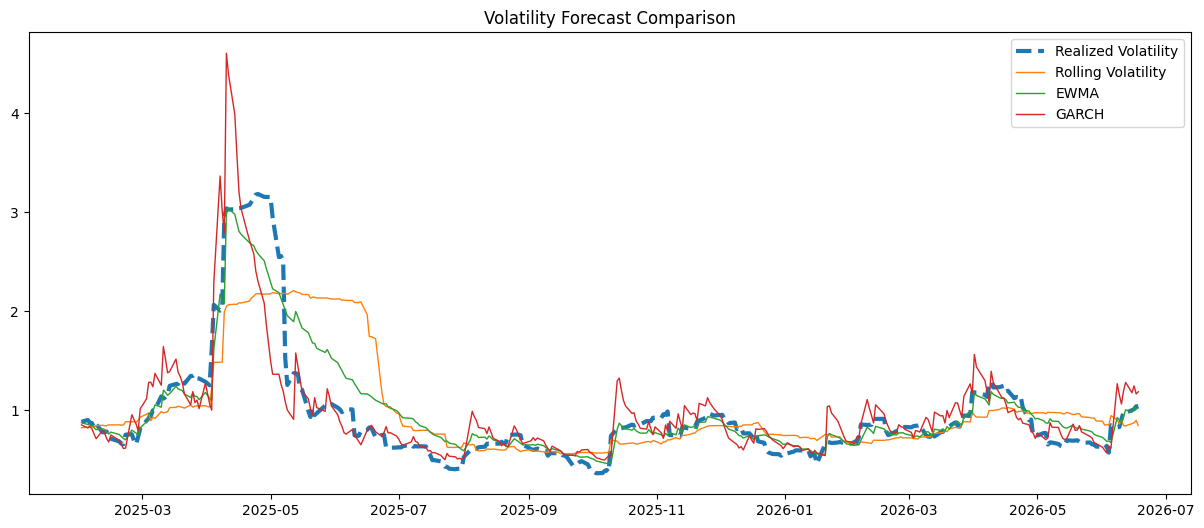

In [96]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison["Realized"],
    label="Realized Volatility",
    linewidth=3,
    linestyle="--"
)

plt.plot(
    comparison["Rolling"],
    label="Rolling Volatility",
    linewidth=1
)

plt.plot(
    comparison["EWMA"],
    label="EWMA",
    linewidth=1
)

plt.plot(
    comparison["GARCH"],
    label="GARCH",
    linewidth=1
)

plt.legend()
plt.title("Volatility Forecast Comparison")
plt.show()

In [97]:
comparison["Rolling_Error"] = (
    comparison["Realized"]
    - comparison["Rolling"]
)

comparison["EWMA_Error"] = (
    comparison["Realized"]
    - comparison["EWMA"]
)

comparison["GARCH_Error"] = (
    comparison["Realized"]
    - comparison["GARCH"]
)

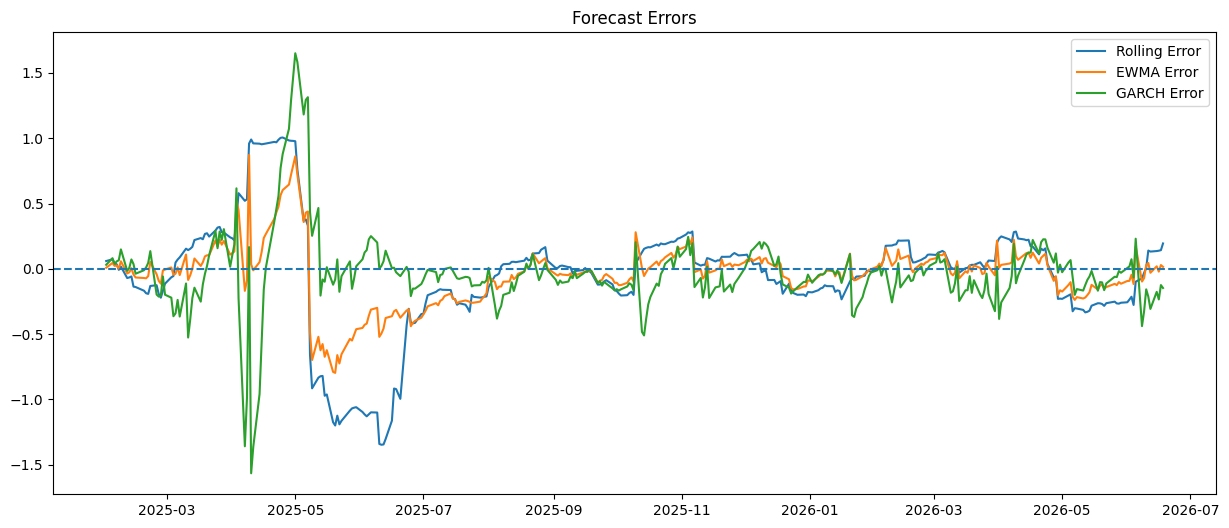

In [98]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison["Rolling_Error"],
    label="Rolling Error"
)

plt.plot(
    comparison["EWMA_Error"],
    label="EWMA Error"
)

plt.plot(
    comparison["GARCH_Error"],
    label="GARCH Error"
)

plt.axhline(0, linestyle="--")

plt.legend()
plt.title("Forecast Errors")
plt.show()

In [99]:
print(realized_vol.isna().sum())

19
